# Coupling strength plots

Download data:

In [106]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# -----------------------------
# Paths (EDIT THESE)
# -----------------------------
ROOT = Path(r"D:\Projects\Cavity_response\modes_coupling_info")   # data lives here: ROOT/data/*.npz
HOME_ROOT = Path(r"D:\Projects\Cavity_response_2.0")              # plots will be saved here: HOME_ROOT/plots/

DATA_DIR = ROOT / "data"
PLOTS_DIR = HOME_ROOT / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

cmap = cm.viridis

files = sorted(DATA_DIR.glob("results_*.npz"))
print("Total *.npz files:", len(files))

Total *.npz files: 39


# Helpers

In [107]:
# ---------- data & metadata ----------

from dataclasses import dataclass

@dataclass(frozen=True)
class RunMeta:
    geometry: str
    mode_fam: str
    mode_ind: tuple[int, ...]
    pol: str
    R: float | None
    L: float | None
    Bz: float
    omega: float

    @property
    def mode_str(self) -> str:
        return "".join(str(x) for x in self.mode_ind)

    def _head(self) -> str:
        return "CYLINDER CAVITY" if self.geometry == "cylinder" else "SPHERICAL CAVITY"

    def _geom_str(self) -> str:
        if self.geometry == "cylinder":
            if self.R is None or self.L is None:
                return ""
            return f"R={self.R*100:.1f} cm, L={self.L*100:.2f} cm"
        if self.geometry == "sphere":
            if self.R is None:
                return ""
            return f"R={self.R*100:.1f} cm"
        return ""

    def title_eta(self) -> str:
        return (f"{self._head()}: Coupling strength η(θ) for {self.mode_fam}_{self.mode_str} mode\n"
                f"{self._geom_str()}, Bz={self.Bz} T, ω={self.omega/1e9:.2f} GHz, pol={self.pol}")

    def title_C(self) -> str:
        return (f"{self._head()}: GW coupling strength C(θ) for {self.mode_fam}_{self.mode_str} mode\n"
                f"{self._geom_str()}, Bz={self.Bz} T, ω={self.omega/1e9:.2f} GHz, pol={self.pol}")



def load_npz(path: str | Path) -> tuple[dict, RunMeta]:
    path = Path(path)
    with np.load(path, allow_pickle=True) as data:
        d = {k: data[k] for k in data.files}

    name = path.name.lower()
    if "results_cyl" in name or "_cyl_" in name:
        geometry = "cylinder"
    elif "results_sph" in name or "_sph_" in name:
        geometry = "sphere"
    else:
        geometry = str(d.get("cavity_type", "unknown")).lower()

    meta = RunMeta(
        geometry=geometry,
        mode_fam=str(d["mode_fam"]),
        mode_ind=tuple(int(x) for x in d["mode_ind"]),
        pol=str(d.get("pol", "")),
        R=float(d["R"]) if "R" in d else np.nan,
        L=float(d["L"]) if "L" in d else None,
        Bz=float(d.get("Bz", np.nan)),
        omega=float(d.get("omega", np.nan)),
    )
    return d, meta

def select_files(files, must_contain):
    return [
        p for p in files
        if all(token in p.name for token in must_contain)
    ]


# ---------- math helpers ----------

def mirror_to_2pi(theta: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """theta in [0, pi] -> returns theta_full in [0, 2pi] with mirrored y."""
    theta_m = 2 * np.pi - theta[::-1]
    y_m = y[::-1]
    return np.concatenate([theta, theta_m]), np.concatenate([y, y_m])


def pick_phi_indices(phi: np.ndarray, *, n: int = 8, targets: np.ndarray | None = None) -> np.ndarray:
    if targets is not None:
        return np.array([int(np.argmin(np.abs(phi - p))) for p in targets], dtype=int)
    return np.linspace(0, len(phi) - 1, n, dtype=int)

# ---------- plotting helpers ----------

def style_cartesian(ax: plt.Axes):
    ax.tick_params(axis="both", labelsize=12)
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)
    ax.grid(True, which="both")


def style_polar(ax: plt.Axes, title: str):
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_thetagrids(range(0, 360, 45))
    ax.grid(True, which="both")
    ax.tick_params(axis="both", labelsize=12)
    ax.set_title(title, fontsize=12, pad=18)


def savefig(fig: plt.Figure, outpath: str | Path, *, dpi: int = 250):
    outpath = Path(outpath)
    outpath.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(outpath, dpi=dpi, bbox_inches="tight")

## 1) Plots for different φ (fixed R, L, ...)

Plot `η(θ)` (optional `C(θ)=η²`) for different`φ` from 1 file

In [108]:
# -----------------------------
# Selection criteria (EDIT)
# -----------------------------
must_contain = ["cyl", "L20.00cm", "R10.0cm", "TM010", "Ntheta100", "Nphi10"]
# must_contain = ["sph", "polplus", "R4.5cm", "TM111", "Ntheta50_"] #might be better to use postprocessed files for spherical case
selected = select_files(files, must_contain=must_contain)

print("Selected files:", len(selected))
if not selected:
    raise FileNotFoundError(f"No files matched must_contain={must_contain}.\nSample names: {[p.name for p in files[:10]]}")

d, meta = load_npz(selected[0])

theta = d["theta"]        # [0, pi]
phi = d["phi"]            # (N_phi,)
eta_all = d["eta_all"]    # (N_phi, N_theta)

phi_idx = pick_phi_indices(phi, n=8)
print("Using phi indices:", phi_idx)
print("Geometry:", meta.geometry, "Mode:", f"{meta.mode_fam}_{meta.mode_str}")

Selected files: 1
Using phi indices: [0 1 2 3 5 6 7 9]
Geometry: cylinder Mode: TM_010


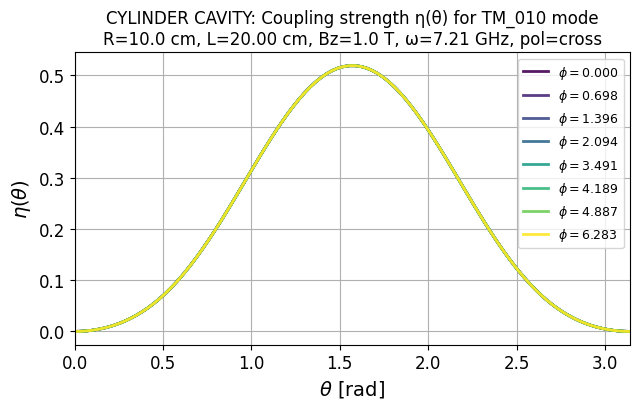

Saved: D:\Projects\Cavity_response_2.0\plots\eta_theta_phi_TM_010.png


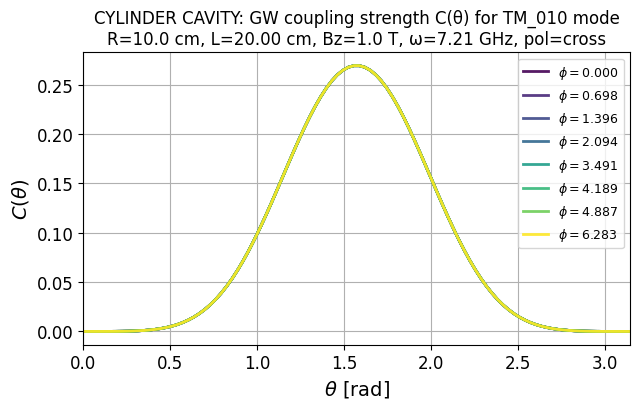

Saved: D:\Projects\Cavity_response_2.0\plots\C_theta_phi_TM_010.png


In [109]:
# Cartesian: η(θ) for selected φ
fig, ax = plt.subplots(figsize=(6.5, 4.2))
style_cartesian(ax)

ax.set_xlim(0, np.pi)
ax.set_xlabel(r"$\theta$ [rad]")
ax.set_ylabel(r"$\eta(\theta)$")
ax.set_title(meta.title_eta())

for i in phi_idx:
    color = cmap(i / max(1, len(phi) - 1))
    ax.plot(theta, eta_all[i], color=color, lw=2, alpha=0.9, label=rf"$\phi={phi[i]:.3f}$")

ax.legend(loc="upper right", frameon=True, fontsize=9)

out = PLOTS_DIR / f"eta_theta_phi_{meta.mode_fam}_{meta.mode_str}.png"
savefig(fig, out)
plt.show()
print("Saved:", out)

# Cartesian C(θ) = η(θ)^2 for selected φ 
fig, ax = plt.subplots(figsize=(6.5, 4.2))
style_cartesian(ax)

ax.set_xlim(0, np.pi)
ax.set_xlabel(r"$\theta$ [rad]")
ax.set_ylabel(r"$C(\theta)$")
ax.set_title(meta.title_C())

for i in phi_idx:
    color = cmap(i / max(1, len(phi) - 1))
    ax.plot(theta, eta_all[i]**2, color=color, lw=2, alpha=0.9, label=rf"$\phi={phi[i]:.3f}$")

ax.legend(loc="upper right", frameon=True, fontsize=9)

out = PLOTS_DIR / f"C_theta_phi_{meta.mode_fam}_{meta.mode_str}.png"
savefig(fig, out)
plt.show()
print("Saved:", out)

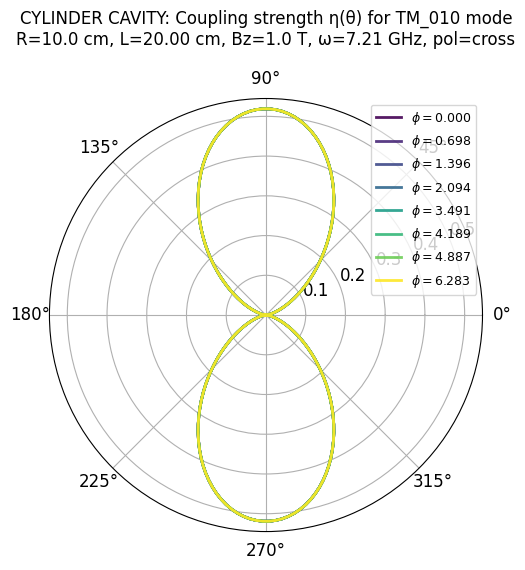

Saved: D:\Projects\Cavity_response_2.0\plots\eta_theta_phi_TM_010_polar.png


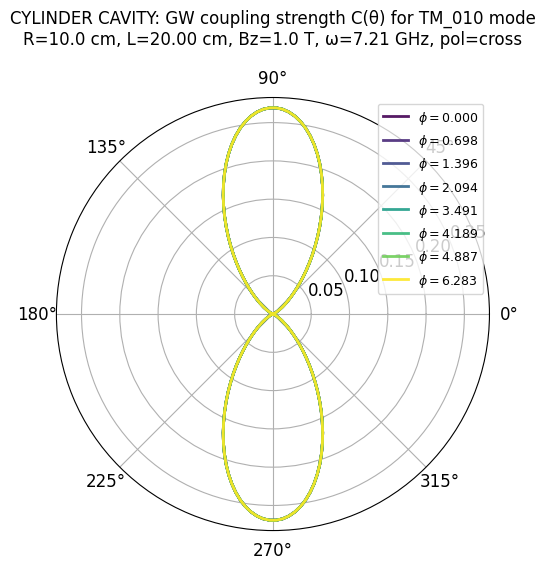

Saved: D:\Projects\Cavity_response_2.0\plots\C_theta_phi_TM_010_polar.png


In [110]:
# Polar: η(θ) for selected φ  (mirror θ -> [0, 2π])
fig = plt.figure(figsize=(6.8, 5.8))
ax = fig.add_subplot(111, projection="polar")
style_polar(ax, meta.title_eta())

for i in phi_idx:
    color = cmap(i / max(1, len(phi) - 1))
    th_full, eta_full = mirror_to_2pi(theta, eta_all[i])
    ax.plot(th_full, eta_full, color=color, lw=2, alpha=0.9, label=rf"$\phi={phi[i]:.3f}$")

ax.legend(loc="upper right", frameon=True, fontsize=9)

out = PLOTS_DIR / f"eta_theta_phi_{meta.mode_fam}_{meta.mode_str}_polar.png"
savefig(fig, out)
plt.show()
print("Saved:", out)

# Polar: C(θ) = η(θ)^2 for selected φ  (mirror θ -> [0, 2π])
fig = plt.figure(figsize=(6.8, 5.8))
ax = fig.add_subplot(111, projection="polar")
style_polar(ax, meta.title_C())

for i in phi_idx:
    color = cmap(i / max(1, len(phi) - 1))
    th_full, eta_full = mirror_to_2pi(theta, eta_all[i])
    ax.plot(th_full, eta_full**2, color=color, lw=2, alpha=0.9, label=rf"$\phi={phi[i]:.3f}$")

ax.legend(loc="upper right", frameon=True, fontsize=9)

out = PLOTS_DIR / f"C_theta_phi_{meta.mode_fam}_{meta.mode_str}_polar.png"
savefig(fig, out)
plt.show()
print("Saved:", out)

## 2) Plots for different R (fixed φ)

Select **a few files** with different `R`, choose fixed `φ` (usually `0`) and plot `η(θ)` and `C(θ)` for comparison.

In [111]:
# -----------------------------
# Selection criteria for different R (EDIT)
# -----------------------------
must_contain_R = ["L20.00cm", "Ntheta1000", "Nphi0", "TE011"]  # example from your original notebook
exclude_substrings = ["om"]  # files containing any of these will be skipped

phi_target = 0.0
use_eta_phi0_if_phi0 = True

selected_R = []
for p in files:
    name = p.name
    if all(t in name for t in must_contain_R) and not any(x in name for x in exclude_substrings):
        selected_R.append(p)

print("Selected files for R-scan:", len(selected_R))
if not selected_R:
    print("No files matched. Sample names:", [p.name for p in files[:10]])

runs = []
for path in selected_R:
    d, metaR = load_npz(path)

    thetaR = d["theta"]
    phiR = d["phi"]
    eta_allR = d["eta_all"]
    R_cm = float(metaR.R) * 100

    j = int(np.argmin(np.abs(phiR - phi_target)))
    phi_used = float(phiR[j])

    if use_eta_phi0_if_phi0 and np.isclose(phi_target, 0.0, atol=1e-12) and "eta_phi0" in d:
        eta_phi = d["eta_phi0"]
        phi_used = 0.0
    else:
        eta_phi = eta_allR[j]

    runs.append((R_cm, thetaR, eta_phi, phi_used, metaR))

runs.sort(key=lambda x: x[0])
print("Runs:", [r[0] for r in runs])

meta_for_titles = runs[0][4] if runs else None

Selected files for R-scan: 5
Runs: [1.0, 2.0, 5.0, 10.0, 30.0]


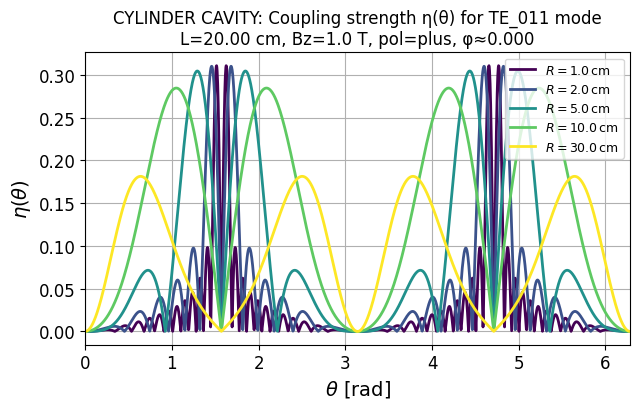

Saved: D:\Projects\Cavity_response_2.0\plots\eta_theta_Rscan_TE_011_plus.png


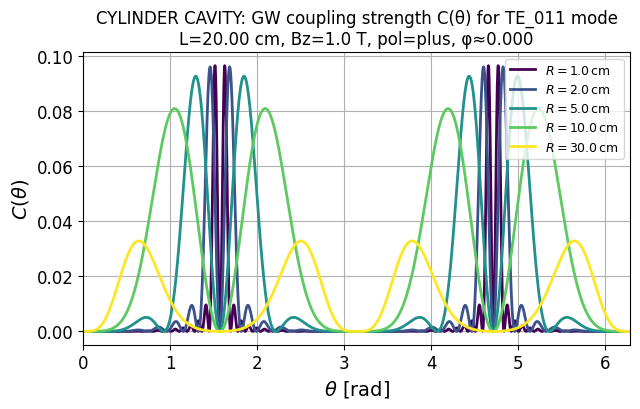

Saved: D:\Projects\Cavity_response_2.0\plots\C_theta_Rscan_TE_011_plus.png


In [112]:
if runs:
    title_eta = (
        f"CYLINDER CAVITY: Coupling strength η(θ) for {meta_for_titles.mode_fam}_{meta_for_titles.mode_str} mode\n"
        f"L={(meta_for_titles.L*100 if meta_for_titles.L else float('nan')):.2f} cm, "
        f"Bz={meta_for_titles.Bz} T, pol={meta_for_titles.pol}, "
        f"φ≈{phi_target:.3f}"
    )
    title_C = (
        f"CYLINDER CAVITY: GW coupling strength C(θ) for {meta_for_titles.mode_fam}_{meta_for_titles.mode_str} mode\n"
        f"L={(meta_for_titles.L*100 if meta_for_titles.L else float('nan')):.2f} cm, "
        f"Bz={meta_for_titles.Bz} T, pol={meta_for_titles.pol}, "
        f"φ≈{phi_target:.3f}"
    )

    # Cartesian: η(θ) mirrored to [0, 2π] (to match original R-compare)
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    style_cartesian(ax)
    ax.set_xlabel(r"$\theta$ [rad]")
    ax.set_ylabel(r"$\eta(\theta)$")
    ax.set_xlim(0, 2*np.pi)
    ax.set_title(title_eta)

    for k, (R_cm, thetaR, eta_phi, phi_used, _) in enumerate(runs):
        color = cmap(k / max(1, len(runs) - 1))
        th_full, eta_full = mirror_to_2pi(thetaR, eta_phi)
        ax.plot(th_full, eta_full, color=color, lw=2, label=fr"$R={R_cm:.1f}\,\mathrm{{cm}}$")

    ax.legend(loc="upper right", frameon=True, fontsize=9)

    out = PLOTS_DIR / f"eta_theta_Rscan_{meta_for_titles.mode_fam}_{meta_for_titles.mode_str}_{meta_for_titles.pol}.png"
    savefig(fig, out)
    plt.show()
    print("Saved:", out)

    # Cartesian: C(θ)
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    style_cartesian(ax)
    ax.set_xlabel(r"$\theta$ [rad]")
    ax.set_ylabel(r"$C(\theta)$")
    ax.set_xlim(0, 2*np.pi)
    ax.set_title(title_C)

    for k, (R_cm, thetaR, eta_phi, phi_used, _) in enumerate(runs):
        color = cmap(k / max(1, len(runs) - 1))
        th_full, eta_full = mirror_to_2pi(thetaR, eta_phi)
        ax.plot(th_full, eta_full**2, color=color, lw=2, label=fr"$R={R_cm:.1f}\,\mathrm{{cm}}$")

    ax.legend(loc="upper right", frameon=True, fontsize=9)

    out = PLOTS_DIR / f"C_theta_Rscan_{meta_for_titles.mode_fam}_{meta_for_titles.mode_str}_{meta_for_titles.pol}.png"
    savefig(fig, out)
    plt.show()
    print("Saved:", out)
else:
    print("Skipping plots: no runs found.")


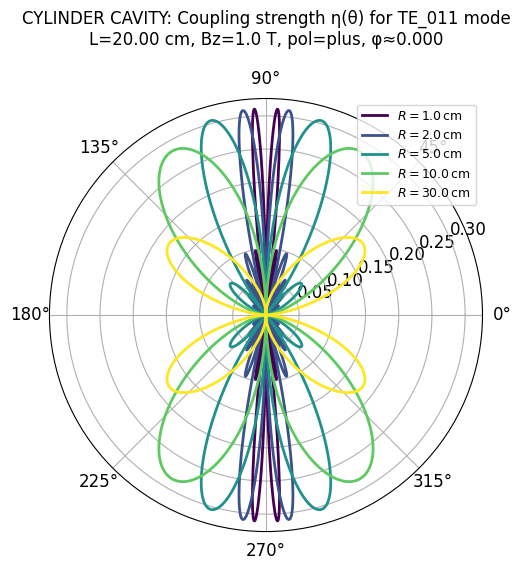

Saved: D:\Projects\Cavity_response_2.0\plots\eta_theta_Rscan_TE_011_plus_polar.png


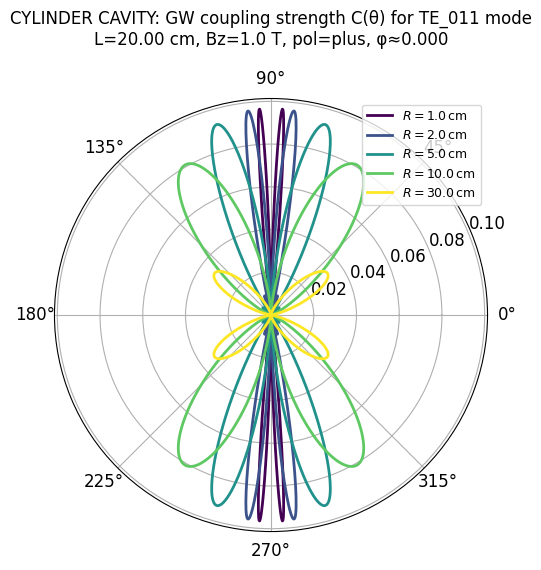

Saved: D:\Projects\Cavity_response_2.0\plots\C_theta_Rscan_TE_011_plus_polar.png


In [113]:
if runs:
    # Polar: η(θ)
    fig = plt.figure(figsize=(6.8, 5.8))
    ax = fig.add_subplot(111, projection="polar")
    style_polar(ax, title_eta)

    for k, (R_cm, thetaR, eta_phi, phi_used, _) in enumerate(runs):
        color = cmap(k / max(1, len(runs) - 1))
        th_full, eta_full = mirror_to_2pi(thetaR, eta_phi)
        ax.plot(th_full, eta_full, color=color, lw=2, label=fr"$R={R_cm:.1f}\,\mathrm{{cm}}$")

    ax.legend(loc="upper right", frameon=True, fontsize=9)
    out = PLOTS_DIR / f"eta_theta_Rscan_{meta_for_titles.mode_fam}_{meta_for_titles.mode_str}_{meta_for_titles.pol}_polar.png"
    savefig(fig, out)
    plt.show()
    print("Saved:", out)

    # Polar: C(θ)
    fig = plt.figure(figsize=(6.8, 5.8))
    ax = fig.add_subplot(111, projection="polar")
    style_polar(ax, title_C)

    for k, (R_cm, thetaR, eta_phi, phi_used, _) in enumerate(runs):
        color = cmap(k / max(1, len(runs) - 1))
        th_full, eta_full = mirror_to_2pi(thetaR, eta_phi)
        ax.plot(th_full, eta_full**2, color=color, lw=2, label=fr"$R={R_cm:.1f}\,\mathrm{{cm}}$")

    ax.legend(loc="upper right", frameon=True, fontsize=9)
    out = PLOTS_DIR / f"C_theta_Rscan_{meta_for_titles.mode_fam}_{meta_for_titles.mode_str}_{meta_for_titles.pol}_polar.png"
    savefig(fig, out)
    plt.show()
    print("Saved:", out)
else:
    print("Skipping plots: no runs found.")


## 3) Quick diagnostics / table of selected file metadata (optional)

In [114]:
import pandas as pd

def meta_row(path: Path) -> dict:
    d, m = load_npz(path)

    eta_all = d["eta_all"]
    eta_max = float(np.max(eta_all))
    C_max = eta_max**2
    C_avg = float(d["C_avg_phi0"]) if "C_avg_phi0" in d else np.nan

    return {
        "file": path.name,
        "geometry": m.geometry,
        "mode_fam": m.mode_fam,
        "mode_ind": m.mode_str,   # або tuple(m.mode_ind)
        "pol": m.pol,
        "R_cm": m.R*100,
        "L_cm": (m.L*100) if m.L is not None else np.nan,
        "Bz_T": m.Bz,
        "omega_GHz": m.omega/1e9,
        "Ntheta": len(d["theta"]),
        "Nphi": len(d["phi"]),
        "eta_max": eta_max,
        "C_max": C_max,
        "C_avg_phi0": C_avg,
    }

# show a compact table for the first 20 files in DATA_DIR
files = sorted(DATA_DIR.glob("*.npz"))
df = pd.DataFrame([meta_row(p) for p in files[:100]])

df = df.sort_values(
    by=["geometry", "mode_fam", "mode_ind", "Ntheta", "Nphi"]
).reset_index(drop=True)

df

,file,geometry,mode_fam,mode_ind,pol,R_cm,L_cm,Bz_T,omega_GHz,Ntheta,Nphi,eta_max,C_max,C_avg_phi0
0,results_cyl_R1.0cm_L20.00cm_B1.0T_modeTE011_po...,cylinder,TE,011,plus,1.0,20.0,1.0,114.968139,100,10,3.025590e-01,9.154194e-02,6.475329e-03
1,results_cyl_R10.0cm_L20.00cm_B1.0T_modeTE011_p...,cylinder,TE,011,plus,10.0,20.0,1.0,12.414945,100,10,2.844840e-01,8.093115e-02,3.857130e-02
2,results_cyl_R2.0cm_L20.00cm_B1.0T_modeTE011_po...,cylinder,TE,011,plus,2.0,20.0,1.0,57.628554,100,10,3.099622e-01,9.607658e-02,1.253689e-02
3,results_cyl_R30.0cm_L20.00cm_B1.0T_modeTE011_p...,cylinder,TE,011,plus,30.0,20.0,1.0,6.069395,100,10,1.812855e-01,3.286441e-02,1.134502e-02
4,results_cyl_R5.0cm_L20.00cm_B1.0T_modeTE011_po...,cylinder,TE,011,plus,5.0,20.0,1.0,23.451989,100,10,3.041976e-01,9.253620e-02,2.745447e-02
5,results_cyl_R1.0cm_L20.00cm_B1.0T_modeTE011_po...,cylinder,TE,011,plus,1.0,20.0,1.0,114.968139,1000,1,3.106555e-01,9.650682e-02,6.474791e-03
6,results_cyl_R10.0cm_L20.00cm_B1.0T_modeTE011_p...,cylinder,TE,011,plus,10.0,20.0,1.0,12.414945,1000,1,2.844995e-01,8.093995e-02,3.856809e-02
7,results_cyl_R2.0cm_L20.00cm_B1.0T_modeTE011_po...,cylinder,TE,011,plus,2.0,20.0,1.0,57.628554,1000,1,3.099816e-01,9.608861e-02,1.253584e-02
8,results_cyl_R30.0cm_L20.00cm_B1.0T_modeTE011_p...,cylinder,TE,011,plus,30.0,20.0,1.0,6.069395,1000,1,1.813001e-01,3.286973e-02,1.134408e-02
9,results_cyl_R5.0cm_L20.00cm_B1.0T_modeTE011_po...,cylinder,TE,011,plus,5.0,20.0,1.0,23.451989,1000,1,3.044412e-01,9.268443e-02,2.745219e-02
